# University of Southampton Visit

Methods comparison in the NATRE region.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import pandas as pd
import numpy as np
from importlib import reload
import cartopy.crs as ccrs
import cmocean.cm as cmo
import gsw
import scipy.ndimage as filter
import scipy.interpolate as interpolate
import mixsea as mx
import warnings

This dataset has vertical gradient terms (mesoscale and microscale) of temperature and salinity calculated on pbar surfaces globally. In this notebook I want to:
- select data from NATRE region only
- calculate K_rho from individual profiles and compare to Whalen K_rho estimates
- compute mesoscale/microscale variance production from both K_rho estimates-->does it make a difference?

Additionally, would be good to have direct comparison between polynomial fit method and coordinate interpolation method. To do this you would need to:
- calculate polynomial fit using T/sig and S/sig profiles
- use this to calculate variance terms

## $K_{\rho}$ Estimates

In [2]:
ds_p = xr.open_dataset('/swot/SUM05/amf2288/ds_p_copilot.nc')
ds_p

<xarray.Dataset>
Dimensions:          (PROFILE: 1488063, PRESSURE: 1001)
Coordinates:
  * PRESSURE         (PRESSURE) int64 0 2 4 6 8 10 ... 1992 1994 1996 1998 2000
    TIME             (PROFILE) datetime64[ns] ...
    LAT              (PROFILE) float64 ...
    LON              (PROFILE) float64 ...
  * PROFILE          (PROFILE) int64 2428701 1114461 2155018 ... 1502504 411205
Data variables: (12/18)
    CT               (PROFILE, PRESSURE) float64 ...
    CYCLE_NUMBER     (PROFILE, PRESSURE) float64 ...
    PLATFORM_NUMBER  (PROFILE, PRESSURE) float64 ...
    PRES             (PROFILE, PRESSURE) float32 ...
    PSAL             (PROFILE, PRESSURE) float32 ...
    SA               (PROFILE, PRESSURE) float64 ...
    ...               ...
    SA_sort          (PROFILE, PRESSURE) float64 ...
    SPICE_sort       (PROFILE, PRESSURE) float64 ...
    PRESSURE_sort    (PROFILE, PRESSURE) int64 ...
    CT_mean          (PROFILE, PRESSURE) float32 ...
    SA_mean          (PROFILE, PRESSURE) float32 ...
    SPICE_mean       (PROFILE, PRESSURE) float32 ...
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         https://data-argo.ifremer.fr
    Fetched_by:           amf2288
    Fetched_date:         2025/03/11
    Fetched_constraints:  [x=0.00/5.00; y=40.00/45.00; z=0.0/2002.0]
    Fetched_uri:          
    Valid uris:           ['https://data-argo.ifremer.fr/dac/coriolis/6903068...
    All uris:             ['https://data-argo.ifremer.fr/dac/coriolis/6903068...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [3]:
mask = ((ds_p.LAT > 20) & (ds_p.LAT < 31) & (ds_p.LON > -38) & (ds_p.LON < -20))
sect_p= ds_p.isel(PROFILE=mask)

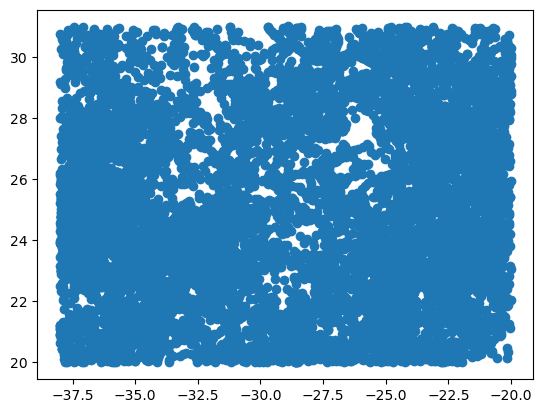

In [4]:
plt.scatter(sect_p.LON, sect_p.LAT)

In [5]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

In [6]:
K_rho_sect = K_rho_p.sel(LAT=slice(20, 31), LON=slice(-38, -20))


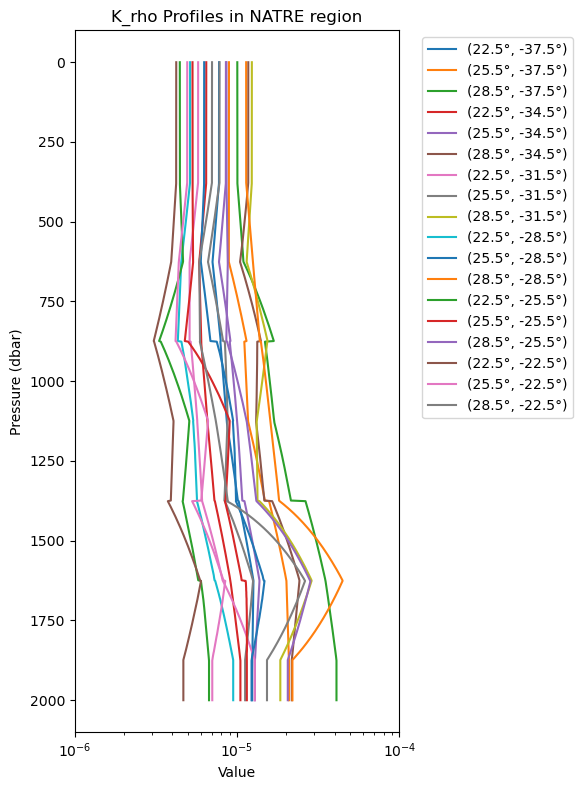

In [7]:
fig, ax = plt.subplots(figsize=(6, 8))

for i, lon in enumerate(K_rho_sect.LON.values):
    for j, lat in enumerate(K_rho_sect.LAT.values):
        profile = K_rho_sect.sel(LON=lon, LAT=lat)
        ax.plot(profile, K_rho_sect.PRESSURE_mean, label=f"({lat:.1f}°, {lon:.1f}°)")

ax.invert_yaxis()
ax.set_xscale('log')
ax.set_xlim(1e-6,1e-4)
ax.set_xlabel("Value")
ax.set_ylabel("Pressure (dbar)")
ax.set_title("K_rho Profiles in NATRE region")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Finescale param code

In [8]:
print(f"Finescale")
# Center points of depth windows. Windows are half overlapping, i.e.
# their size (200m) is double the spacing here (100m).
window_size = 200
min_size = 10.
dZ = window_size // 4
#print("window size {} m, window spacing {} m".format(window_size, dz))
depth_bin = np.arange(dZ, 2000, dZ)
# Wavenumber vector. Starts at wavenumber corresponding to a 200m
# wavelength.
m = np.arange(2 * np.pi / window_size, 2 * np.pi / min_size, 2 * np.pi / window_size)
# Wavenumber indices for integration. Shear is integrated from 300m to
# 100m scales. Strain is integrated from 150m to 30m.
m_include_sh = list(range(3))
m_include_st = list(range(1, 12))

Finescale


In [9]:
print("Finescale")

# Center points of depth windows. Windows are half overlapping.
window_size = 200
min_size = 10.
dZ = window_size // 4
depth_bin = np.arange(dZ, 2000, dZ)

# Wavenumber vector
m = np.arange(2 * np.pi / window_size,
              2 * np.pi / min_size,
              2 * np.pi / window_size)

m_include_sh = list(range(3))
m_include_st = list(range(1, 12))

ds = sect_p

N_PROF = ds.dims["PROFILE"]
N_DEPTH = depth_bin.size
eps_st  = np.full((N_DEPTH, N_PROF), np.nan)
Krho_st = np.full((N_DEPTH, N_PROF), np.nan)
depth_st = np.tile(depth_bin[:, None], (1, N_PROF))  # fixed grid

for i in range(N_PROF):

    Z = ds.PRESSURE.values
    Tprof = ds["CT"].isel(PROFILE=i).values
    Sprof = ds["SA"].isel(PROFILE=i).values
    lon_i = ds["LON"].isel(PROFILE=i).item()
    lat_i = ds["LAT"].isel(PROFILE=i).item()

    # Require enough valid data
    if np.sum(np.isfinite(Tprof + Sprof)) < 100:
        continue

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)

            eps_shst, krho_shst, diag = mx.shearstrain.nan_shearstrain(
                Z,
                Tprof,
                Sprof,
                lon_i,
                lat_i,
                np.zeros_like(Tprof),   # dummy shear
                np.zeros_like(Tprof),   # dummy shear
                Z,
                m=m,
                depth_bin=depth_bin,
                window_size=window_size,
                m_include_sh=m_include_sh,
                m_include_st=m_include_st,
                ladcp_is_shear=False,   # <-- IMPORTANT
                smooth="AL",
                return_diagnostics=True,
            )

        # Extract actual depth vector returned by the algorithm
        depth_raw = diag["depth_bin"]

        # Mask invalid values
        valid = np.isfinite(depth_raw) & np.isfinite(krho_shst) & np.isfinite(eps_shst)

        if np.sum(valid) < 4:
            print(f"Skipped profile {i}: too few valid points for interpolation")
            continue

        # Interpolate onto fixed depth grid
        Krho_st[:, i] = np.interp(depth_bin, depth_raw[valid], krho_shst[valid])
        eps_st[:, i]  = np.interp(depth_bin, depth_raw[valid], eps_shst[valid])

    except ValueError as e:
        print(f"Skipped profile {i} due to error: {e}")
        continue

print("complete")

Finescale


/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


Skipped profile 26 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 39 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 47 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 56 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 92 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 240 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 419 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 519 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 545 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 552 due to error: zero-size array to reduction operation maxim

/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/mixsea/nsq.py:254: RankWarning: Polyfit may be poorly conditioned
  p[:, i] = np.polyfit(Pb[:imax, i], sv[:imax, i], order)
/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/mixsea/nsq.py:254: RankWarning: Polyfit may be poorly conditioned
  p[:, i] = np.polyfit(Pb[:imax, i], sv[:imax, i], order)
/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/mixsea/nsq.py:254: RankWarning: Polyfit may be poorly conditioned
  p[:, i] = np.polyfit(Pb[:imax, i], sv[:imax, i], order)
/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/mixsea/nsq.py:254: RankWarning: Polyfit may be poorly conditioned
  p[:, i] = np.polyfit(Pb[:imax, i], sv[:imax, i], order)
/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/mixsea/nsq.py:254: RankWarning: Polyfit may be poorly conditioned
  p[:, i] = np.polyfit(Pb[:imax, i], sv[:imax, i], order)
/home/amf2288/miniconda3/

Skipped profile 6018 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 6044 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 6172 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 6267 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 6459 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 6471 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 6540 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 6558 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 6698 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile 6723 due to error: zero-size array to reduction 

In [10]:
Krho_st

array([[ 0., nan, nan, ...,  0.,  0.,  0.],
       [ 0., nan, nan, ...,  0.,  0.,  0.],
       [ 0., nan, nan, ...,  0.,  0.,  0.],
       ...,
       [ 0., nan, nan, ...,  0.,  0.,  0.],
       [ 0., nan, nan, ...,  0.,  0.,  0.],
       [ 0., nan, nan, ...,  0.,  0.,  0.]])

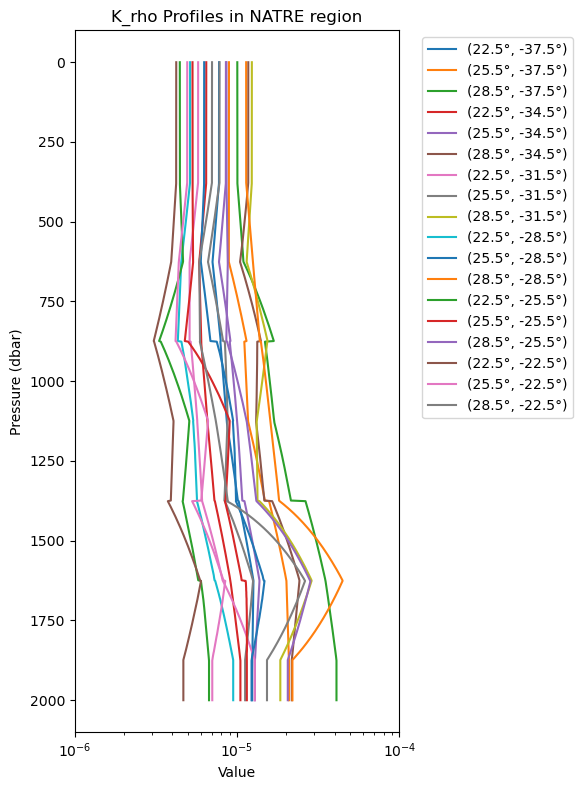

In [11]:
plt.figure(figsize=(6,8))

for i, lon in enumerate(K_rho_sect.LON.values):
    for j, lat in enumerate(K_rho_sect.LAT.values):
        profile = K_rho_sect.sel(LON=lon, LAT=lat)
        plt.plot(profile, K_rho_sect.PRESSURE_mean, label=f"({lat:.1f}°, {lon:.1f}°)")

for n in range(0,len(Krho_st)):
    profile = Krho_st[:,n]
    depth = depth_st[:,n]
    plt.plot(profile, depth, color='k', linewidth=1, alpha=0.5)

plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlim(1e-6,1e-4)
plt.xlabel("Value")
plt.ylabel("Pressure (dbar)")
plt.title("K_rho Profiles in NATRE region")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
density (26.75, 28, 0.05)